# LOGISTIC REGRESSION

### 1. Data Exploration:
#### a. Load the dataset and perform exploratory data analysis (EDA).
#### b. Examine the features, their types, and summary statistics.
#### c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
#### Analyze any patterns or correlations observed in the data.

In [1]:
## import required libraries..
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
df_train = pd.read_csv("Titanic_train.csv")
## Loading the training data..

In [3]:
df_train.head()

## This dataset contains information about passengers aboard the Titanic..
## The training dataset consists of 891 observations and 12 variables as we can see in below step.. df_train.info() ..
## The "Survived" column is the target variable, indicating whether a passenger survived (1) or not (0).. 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df_train.info()

## The dataset contains mix of numerical and categorical variables..
## Missing values can be seen in some colums like Age, Cabin and Embarked in the dataset..
## Cabin contains a large number of missing values and may have to dropped later..
## Age (177) and Embarked (2) require imputation..

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df_train.describe()

## The average passenger Age is 29.7 years with values ranging from 0.42 to 80 years..
## The average fair paid is around 32.2, with a maximum value of 512 indicating the presence of outliers..
## The mean survival rate is 0.38, meaning around 38% of the passengers survived..
## Most passengers have 0 sibling/spouses (SibSp) and 0 psarents/children (Parch) means many passengers were travelling alone..

## The target variable is kind of imbalanced with fewer survivors compared to non survivors.. 

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


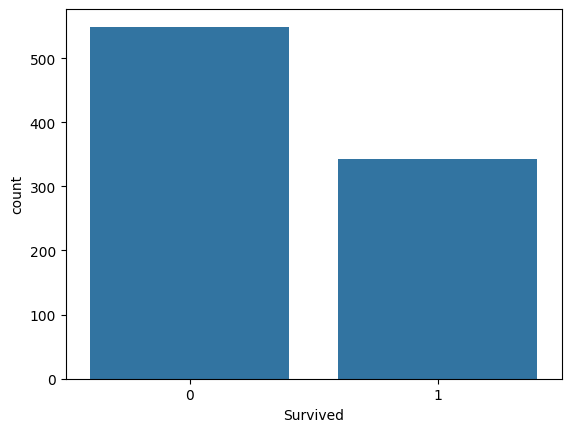

Survived
0    549
1    342
Name: count, dtype: int64


In [6]:
sns.countplot(x = "Survived", data = df_train)
plt.show()

print(df_train["Survived"].value_counts())

## The count plot of the target variable shows that the number of passenger who did not survive (549) is higher than those who survived (342)..
## This indicates a slight class imbalance in the dataset..

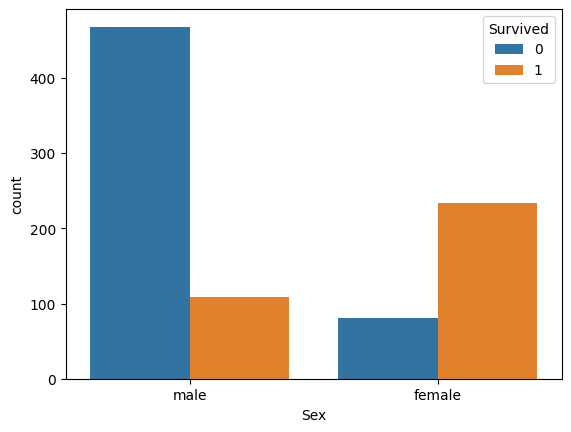

Sex
female    233
male      109
Name: Survived, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64


In [7]:
## Survival vs Gender 
sns.countplot(x = "Sex", hue = "Survived", data = df_train)
plt.show()

print(df_train.groupby("Sex")["Survived"].sum()) # Total survivors by gender..
print(df_train["Sex"].value_counts())
## The visualisation shows that a significantly higher proportion of females survived (74%) compared to males (18%)..
## Most male passengers did not survive, indicating that gender played a crucial role in survival..

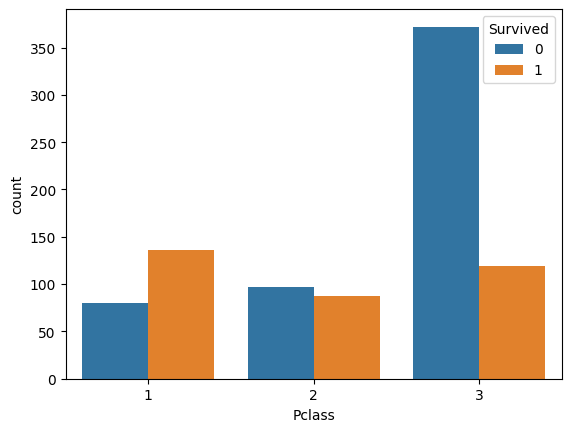

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [8]:
## Survival vs Passenger class
sns.countplot(x = "Pclass", hue = "Survived", data = df_train)
plt.show()


print(df_train.groupby("Pclass")["Survived"].sum())
print(df_train["Pclass"].value_counts())
## Passenger in Pclass = 1 had a higher survival rate (62.96%) compared to those in middle (47%) and lower class (24%)..
## Most passengers in Pclass = 3 did not survive, it suggests that somehow socio-economic status influenced survival chance..
## the highest number of survivors is in Pclass = 1 (136), followed by Pclass 3 (119) then Pclass 2 (87).. 

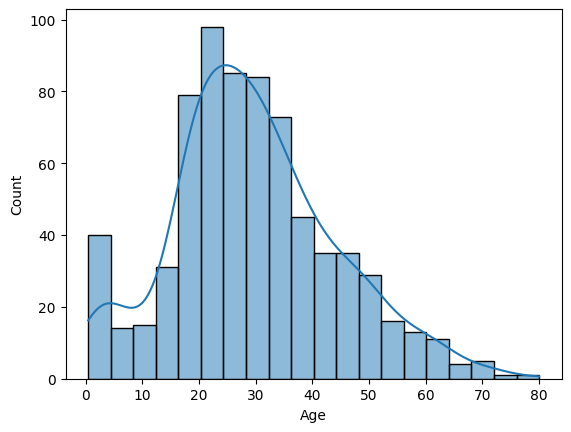

In [9]:
## Age distribution..
sns.histplot(df_train["Age"],kde = True)
plt.show()

## The age distribution shows that most passengers were between 20-40 years old..
## The distribution is slightly right skewed and missing values are present in this feature..

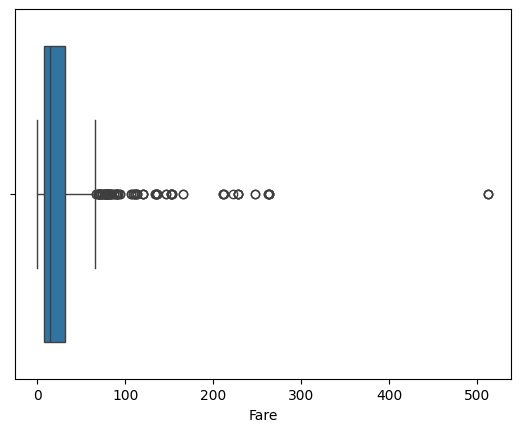

In [10]:
## Fare distribution..
sns.boxplot(x = df_train["Fare"])
plt.show()

## The boxplot of fare shows the presence of several high value outliers
## indicating that a few passenger paid significantly higher fares compared to majority, also beacuse mean is near lower whisker..

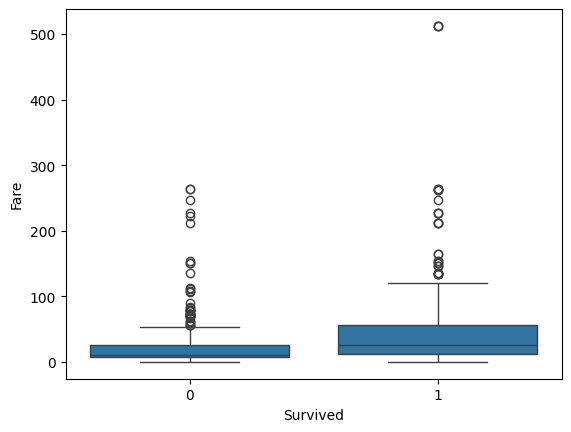

Survived
0    10.5
1    26.0
Name: Fare, dtype: float64


In [11]:
## Survival vs Fare..
sns.boxplot(x = "Survived", y = "Fare", data = df_train)
plt.show()

print(df_train.groupby("Survived")["Fare"].median())

## Passengers who survived tend to have paid higher fares on average suggesting that wealthier passengers had better chances of survival..
## Median fare of survivors (26) is higher than that of non survivors (10.5)..

### 2. Data Preprocessing:
#### a. Handle missing values (e.g., imputation).
#### b. Encode categorical variables.

In [12]:
## This step is very important.. we will do this step on both training and testing data..
## Lets load testing data as well..
df_test = pd.read_csv("Titanic_test.csv")
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [13]:
df_test.info()

## There are total of 418 entries in testing dataset.
## There are few missing values in Age column and 1 missing value in Fare column..
## There are many missing entries/null values (around 78%) in Cabin column ().. 
## The target variable (Survived) is missing in the testing dataset..

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [14]:
## lets drop unnecessary columns from both training and testing dataset..
## we will drop Cabin also because most of the entries from this columns are not available..
drop_cols = ["PassengerId", "Ticket", "Name", "Cabin"]

df_train = df_train.drop(columns = drop_cols)
df_test = df_test.drop(columns = drop_cols)

In [15]:
print(df_test.columns)
print(df_train.columns)

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='object')
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


In [16]:
## Handelling missing values
## We will fill using train dataset only to handel missing values in both training and testing dataset..

## Age column
mean_age = df_train["Age"].mean()

df_train["Age"].fillna(mean_age, inplace = True)
df_test["Age"].fillna(mean_age, inplace = True)

## I got warning while trying to run : df_train["Age"].fillna(mean_age, inplace = True)
## Warning ----> 
## FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
## The behavior will change in pandas 3.0. 
## This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.
## For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or
## df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.

## So if above code doesn't work and shows error at the time of submission than below code can be used :

## df_train.fillna({"Age": mean_age}, inplace=True)
## df_test.fillna({"Age": mean_age}, inplace=True)

## Or

## df_train["Age"] = df_train["Age"].fillna(mean_age)
## df_test["Age"] = df_test["Age"].fillna(mean_age)

C:\Users\devlok\AppData\Local\Temp\ipykernel_7888\3130180169.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["Age"].fillna(mean_age, inplace = True)
C:\Users\devlok\AppData\Local\Temp\ipykernel_7888\3130180169.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [17]:
## Embarked column, filled using mode
mode_embarked = df_train["Embarked"].mode()[0]

df_train["Embarked"] = df_train["Embarked"].fillna(mode_embarked)
df_test["Embarked"] = df_test["Embarked"].fillna(mode_embarked)

In [18]:
## Fare
## missing values in this column only in test dataset..
df_test["Fare"] = df_test["Fare"].fillna(df_train["Fare"].mean())

In [19]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [20]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       418 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      418 non-null    float64
 6   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 23.0+ KB


In [21]:
## Encoding categorical variable (Sex, Embarked)..
## We will be using one hot encoding..

df_train = pd.get_dummies(df_train, columns = ["Sex", "Embarked"], drop_first = True)
df_test = pd.get_dummies(df_test, columns = ["Sex", "Embarked"], drop_first = True)

In [22]:
## Lets check if all the columns are transferred in numerical format or not.. 
print(df_train.info())
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      418 non-null    int64  
 1   Age         418 non-null    float64
 2   SibSp       418 non-null    int64  
 3   Parch       418 non-null    int64  
 4   Fare        418 non-null 

In [23]:
print(df_test.columns)
print(df_train.columns)

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')
Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [24]:
## now lets define X and Y to feed the model for training..
X_train = df_train.drop("Survived", axis = 1)
Y_train = df_train["Survived"]

print(X_train.columns)
print(Y_train)

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')
0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


In [25]:
## Testing data..
## Usually target variable is missing in test dataset.. here also it is missing..
X_test = df_test.copy()
print(X_test.columns)

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')


In [26]:
## During preprocessing unnecessary features such as PassengerId, Name, Ticket and Cabin were removed..
## Missing values in Age were imputed using the mean, while Embarked was filled using the mode..
## Fare value in the dataset were also imputed..
## Categorical value such as Sex and Embarked were converted into numerical form using one-hot encoding.. 

### 3. Model Building
#### a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).
#### b. Train the model using the training data.

In [27]:
## Lets import model..
from sklearn.linear_model import LogisticRegression

In [28]:
## Create model..
model = LogisticRegression(max_iter = 1000)

In [29]:
## Train
model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
## Model prediction..
Y_prediction = model.predict(X_test)

In [31]:
## Since the given test dataset does not have Target variable, so we will use train dataset for evaluation..
## we will crete a small split only for evaluation 
from sklearn.model_selection import train_test_split
X_tr, X_eval, Y_tr, Y_eval = train_test_split(X_train, Y_train, test_size = 0.2, random_state = 42)

model.fit(X_tr, Y_tr)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
## prediction for model evaluation..
Y_eval_pred = model.predict(X_eval)

In [33]:
## A logistic regression model was built using the training dataset..
## The model was trained using the input features to predict the survival status of passengers..
## Logistic regression is suitable for binary classification problems as it predicts the probability of class membership..

### 4. Model Evaluation:
#### a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.
#### Visualize the ROC curve.

In [34]:
## import 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

In [35]:
## Metrics
print("Accuracy: ", accuracy_score(Y_eval, Y_eval_pred))
print("Precision: ", precision_score(Y_eval, Y_eval_pred))
print("Recall: ", recall_score(Y_eval, Y_eval_pred))
print("F1 Score: ", f1_score(Y_eval, Y_eval_pred))

Accuracy:  0.8100558659217877
Precision:  0.7857142857142857
Recall:  0.7432432432432432
F1 Score:  0.7638888888888888


In [36]:
## Confusion matrics
cm = confusion_matrix(Y_eval, Y_eval_pred)
print(cm)

[[90 15]
 [19 55]]


In [37]:
## classification report..
## this gives all metrics together at once.. 
print(classification_report(Y_eval, Y_eval_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [38]:
## ROC AUC Score
Y_eval_prob = model.predict_proba(X_eval)[:, 1]
print("ROC-AUC Score: ", roc_auc_score(Y_eval, Y_eval_prob))

ROC-AUC Score:  0.8818532818532818


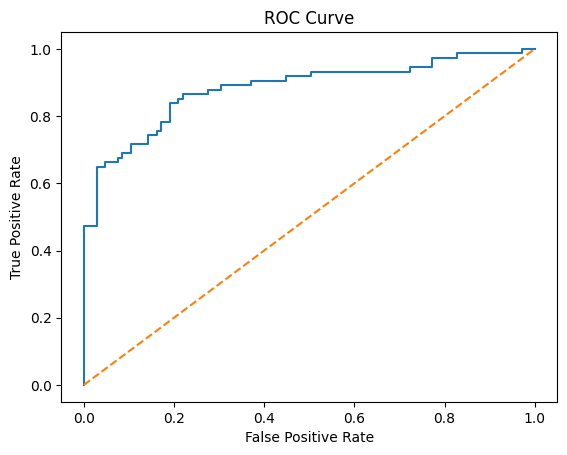

In [39]:
## ROC Curve
fpr, tpr, thresholds = roc_curve(Y_eval, Y_eval_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle = "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [40]:
## The logistic regression model shows good performace overall..
## The model achieved an accuracy of 81% which means it correctly predicted the survival status for most passengers..

##The precision score of 0.78 indicates that out of all the passengers predicted as survived, about 78% were actually correct..
## The recall score of 0.74 shows that the model was able to correctly identify around 74% of the actual survivors.. 
## The F1 score of 0.76 provides a balanced measure of both precision and recall,shows a reasonably good model performace.. 

## The confusion matrix shows that the model correctly predicted 90 non survivors and 55 survivers..
## while it misclassified 15 non survivor as survivors and 19 survivors as non survivors..

## The ROC-AUC score of 0.88 indicates that the model has a strong ability to distinguish between survivors and non survivors..
## The ROC curve also lies well above the diagonal line which confirms that the model performs significantly better than random guessing..

## 5. Interpretation

In [41]:
## model coefficients.. 
coeff_df = pd.DataFrame({"Features": X_train.columns, "Coefficients": model.coef_[0]})
print(coeff_df.sort_values(by = "Coefficients", ascending = False))

     Features  Coefficients
4        Fare      0.002547
1         Age     -0.031352
6  Embarked_Q     -0.092458
3       Parch     -0.111333
2       SibSp     -0.297125
7  Embarked_S     -0.406065
0      Pclass     -0.940992
5    Sex_male     -2.590830


In [42]:
## The coefficcient of the logistic regression model show how each feature affects the probability of survival..

## The variable Sex_male (-2.59) has the strongest negative impact, indicating that male passenger had much lower chance of survival compared to females..

## The Pclass (-0.94) coefficients is also strongly negative which means passengers in lower class had a lower probability of survival..
## This shows that passenger in higher classes were more likely to survive..

## The Age(-0.03) coefficient suggests that as age increases the chance of survival slightly decreases..
## Younger passengers had a better chance of survival..

## The variable SibSp (-0.29) and Parch (-0.11) also have negative coefficients which means passenger travelling with more family members had a slightly lower chance of survival..

## The Fare (0.0025) coefficient is positive indicating that passengers who paid higher fares had a slightly higher probability of survival..

## The variable Embarked_S (-0.40) and Embarked_Q (-0.09) have negative effects compared to the reference category..
## It suggests that the port of embarkation also had some influence on survival probability..

## Overall the model indicates that gender passenger class, and fare are the most important factors affecting survival..

In [43]:
df_train.corr()

## Multicollinearity wasn't explicitly analyzed as logistic regression is less sensitive to it comapred to linear regression..
## and the focus of this analysis is on classification performance, not on coefficient stability..
## Yes multicollinearity can affect coefficient interpretation, but it would not significantly impact prediction performance..
## anyway i checked just to be sure, and i found that all the value are around moderate level only (+0.5 to -0.5).. no extreme values were present..

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
Survived,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307,-0.543351,0.003650,-0.149683
Pclass,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500,0.131900,0.221009,0.074053
Age,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566,0.084153,-0.013855,-0.019336
SibSp,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651,-0.114631,-0.026354,0.068734
Parch,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225,-0.245489,-0.081228,0.060814
Fare,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000,-0.182333,-0.117216,-0.162184
Sex_male,-0.543351,0.131900,0.084153,-0.114631,-0.245489,-0.182333,1.000000,-0.074115,0.119224
Embarked_Q,0.003650,0.221009,-0.013855,-0.026354,-0.081228,-0.117216,-0.074115,1.000000,-0.499421
Embarked_S,-0.149683,0.074053,-0.019336,0.068734,0.060814,-0.162184,0.119224,-0.499421,1.000000


In [44]:
dt_train = pd.read_csv("Titanic_train.csv")
print(dt_train.columns)
dt_test = pd.read_csv("Titanic_test.csv")
print(dt_test.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


### 6. Deployment with Streamlit:
#### In this task, you will deploy your logistic regression model using Streamlit..
#### The deployment can be done locally or online via Streamlit Share..
#### Your task includes creating a Streamlit app in Python that involves loading your trained model and setting up user inputs for predictions..

In [45]:
## Now Deployment with streamlit..
## Now lets save the trained model.. 

import pickle
with open("logistic_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


In [46]:
## The trained Logistic Regression model has been saved using Pickle library..
## Saving the model allows it to reused without retraining and enables deployment in a Strealit application for real time predictions..

In [47]:
## The trained Logistic Regression model was saved using the Pickle library and deployed locally using Streamlit..
## A user-friendly interface was created to accept passenger details as input and generate survival predictions..
## To make the application more realistic and avoid invalid combinations the embarkation point was provided as a single dropdown option (C, Q, or S)..
## Which was internally converted into the one-hot encoded variables (Embarked_Q and Embarked_S) required by the trained model..
## This deployment demonstrates how a machine learning model can be integrated into an interactive application for real-time prediction..

### Interview Questions:
#### 1. What is the difference between precision and recall?
#### 2. What is cross-validation, and why is it important in binary classification?

In [48]:
## Precision and recall are performance metrics used to evaluate classification models like logistic regression..
## Precision measures how many predicted positive cases are actually correct, focusing on accuracy of positive predictions..
## Recall measures how many actual positive cases are correctly identified, emphasizing completeness..
## High precision reduces false positives while high recall reduces false negative..
## Balancing both is important depending on the problem..


## Cross validation is a technique used to evaluate binary classification models by splitting the datset into multiple subsets..
## Training on some part and tesing on other parts repeatedly..
## It ensure the model performs well on unseen data..
## This is important because it reduces overfitting, improves reliability of results and provide more accurate estimate of model performance..